In [4]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [5]:
import pandas as pd
df = pd.read_csv('netflix_titles.csv')

In [6]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [14]:
df_clean = df.copy()

In [15]:
cols_fill = ['director','cast','country','rating','duration']

for col in cols_fill:
    df_clean[col] = df_clean[col].fillna('Unknown')

In [16]:
#remove missing dates
df_clean = df_clean.dropna(subset=['date_added'])

In [17]:
df_clean.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [18]:
df_clean.isnull().values.any()

np.False_

In [19]:
df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


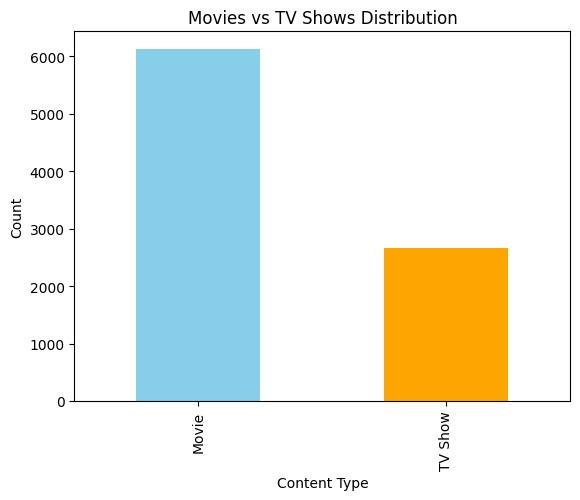

In [22]:
import matplotlib.pyplot as plt

df_clean['type'].value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.title('Movies vs TV Shows Distribution')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

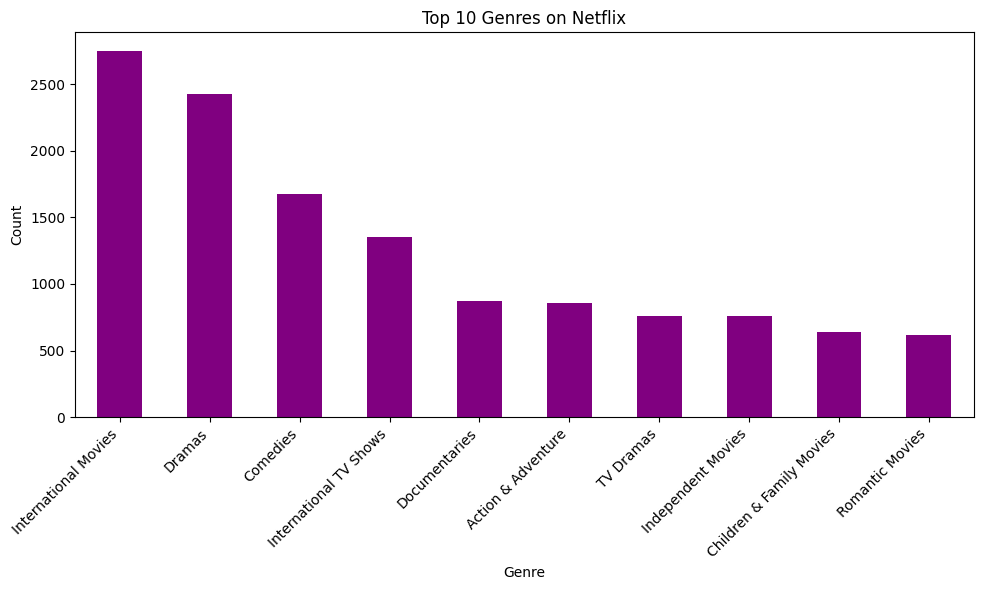

In [23]:
import matplotlib.pyplot as plt

# split genres
genres = df_clean['listed_in'].str.split(',', expand=True).stack()

# remove extra spaces
genres = genres.str.strip()

# get top 10 genres
top_genres = genres.value_counts().head(10)

# plot
plt.figure(figsize=(10,6))
top_genres.plot(kind='bar', color='purple')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.xticks(rotation=45, ha='right')  # rotate labels so they don't overlap

plt.tight_layout()  # adjust spacing
plt.show()

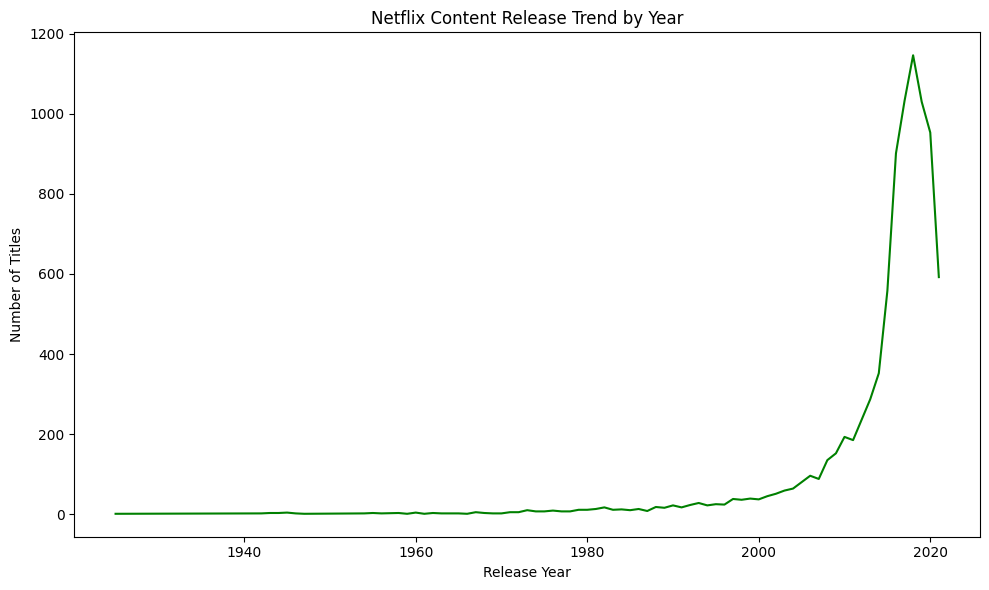

In [24]:
import matplotlib.pyplot as plt

# count content by release year
year_counts = df_clean['release_year'].value_counts().sort_index()

# plot
plt.figure(figsize=(10,6))
year_counts.plot(kind='line', color='green')

plt.title('Netflix Content Release Trend by Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

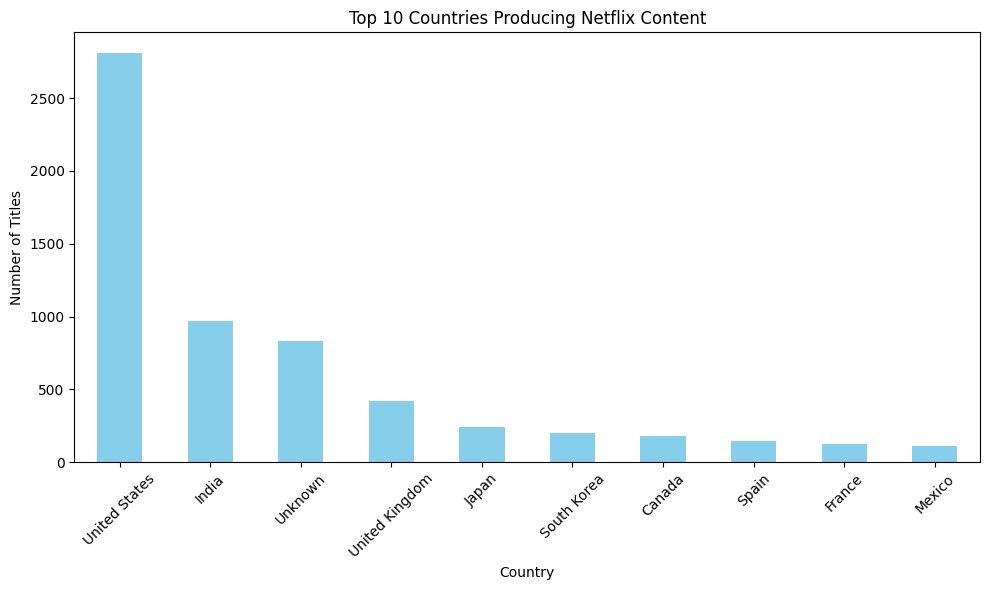

In [25]:
import matplotlib.pyplot as plt

# get country counts
top_countries = df_clean['country'].value_counts().head(10)

# plot
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar', color='skyblue')

plt.title('Top 10 Countries Producing Netflix Content')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

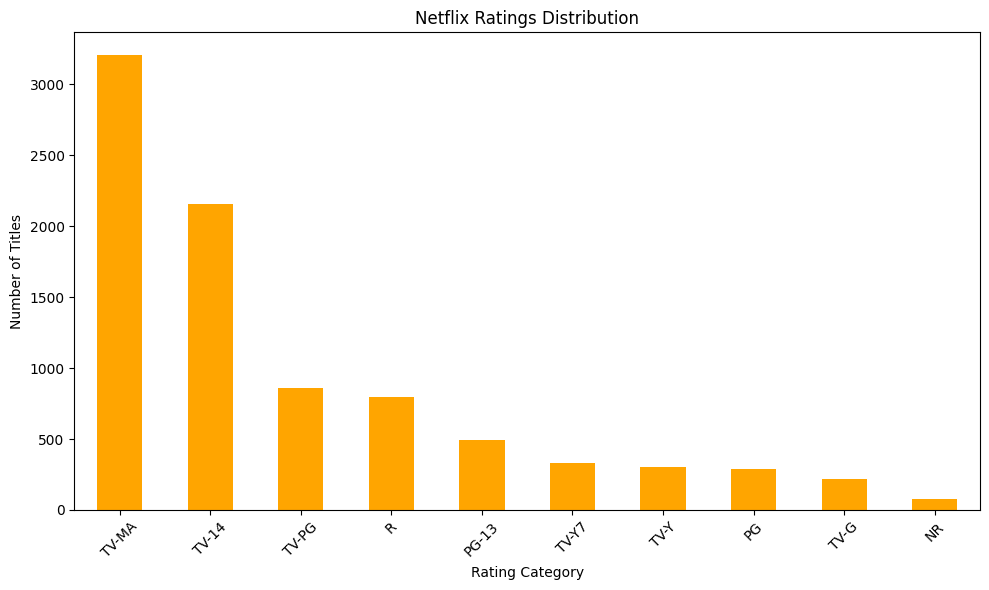

In [26]:
import matplotlib.pyplot as plt

# count ratings
rating_counts = df_clean['rating'].value_counts().head(10)

# plot
plt.figure(figsize=(10,6))
rating_counts.plot(kind='bar', color='orange')

plt.title('Netflix Ratings Distribution')
plt.xlabel('Rating Category')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Rating categories indicate the target audience age group for Netflix content. For example, TV-MA represents mature audiences, TV-14 targets teenagers, and PG-13 indicates parental guidance for viewers under 13.

In [27]:
# select only movies
movies = df_clean[df_clean['type'] == 'Movie']

# extract numbers from duration
movies['duration_int'] = movies['duration'].str.extract('(\d+)')

# remove rows with missing duration
movies = movies.dropna(subset=['duration_int'])

# convert to integer
movies['duration_int'] = movies['duration_int'].astype(int)

<>:5: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_9891/2813268299.py:5: SyntaxWarning: invalid escape sequence '\d'
  movies['duration_int'] = movies['duration'].str.extract('(\d+)')
/tmp/ipykernel_9891/2813268299.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  movies['duration_int'] = movies['duration'].str.extract('(\d+)')


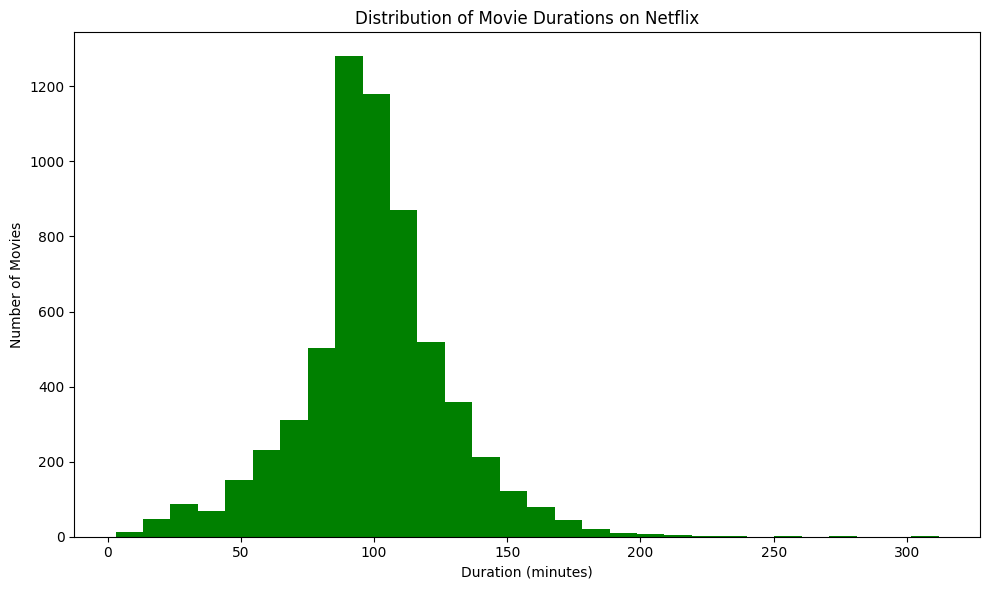

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(movies['duration_int'], bins=30, color='green')

plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()

**Sentiment** **Analysis**

Dataset has a column called **description**, which contains short summaries of movies/shows.
Analyze the sentiment of those descriptions (positive, negative, neutral).

Sentiment Analysis of **Descriptions**

In [29]:
!pip install textblob
#!pip install library Install library inside Colab

In [30]:
from textblob import TextBlob

In [31]:
def get_sentiment(text):
    return TextBlob(str(text)).sentiment.polarity

df_clean['sentiment_score'] = df_clean['description'].apply(get_sentiment)

In [32]:
def sentiment_label(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_clean['sentiment'] = df_clean['sentiment_score'].apply(sentiment_label)

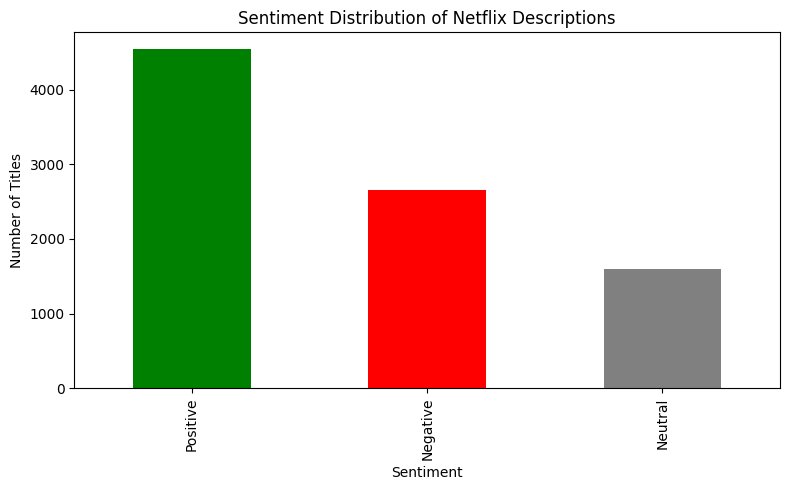

In [33]:
import matplotlib.pyplot as plt

sentiment_counts = df_clean['sentiment'].value_counts()

plt.figure(figsize=(8,5))
sentiment_counts.plot(kind='bar', color=['green','red','gray'])

plt.title('Sentiment Distribution of Netflix Descriptions')
plt.xlabel('Sentiment')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

Sentiment analysis was performed on the content descriptions using the TextBlob library to identify whether the descriptions convey positive, negative, or neutral sentiment.

In [34]:
df_clean.to_csv('netflix_cleaned_dataset.csv', index=False)

In [35]:
from google.colab import files
files.download('netflix_cleaned_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##  ML Model - Predict Movie or TV Show
We will predict whether a Netflix title is a **Movie or TV Show** based on its duration, rating and release year.

In [36]:
# Step 1 - Import ML libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder

print('Libraries imported!')

Libraries imported!


In [37]:
# Step 2 - Prepare columns for ML
# ML only understands numbers, so we convert text columns to numbers

df_ml = df_clean.copy()

# Convert rating (like TV-MA, PG-13) into numbers
le = LabelEncoder()
df_ml['rating_encoded'] = le.fit_transform(df_ml['rating'])

# Extract number from duration (like '90 min' -> 90)
#ml['duration_value'] = df_ml['duration'].str.extract(r'(\d+)').astype(float)

print('Data prepared!')

Data prepared!


In [39]:
# Step 3 - Choose input columns and what to predict

# 2 clues given to model
X = df_ml[['release_year', 'rating_encoded']]

# This is what we want the model to GUESS (1 = Movie, 0 = TV Show)
y = (df_ml['type'] == 'Movie').astype(int)

print('Input columns (X):', X.columns.tolist())
print('Target (y): 1 = Movie, 0 = TV Show')

Input columns (X): ['release_year', 'rating_encoded']
Target (y): 1 = Movie, 0 = TV Show


In [40]:
# Step 4 - Split data into Training and Testing
# 80% data = model learns from it
# 20% data = we check if model learned correctly

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Testing samples:', X_test.shape[0])

Training samples: 7037
Testing samples: 1760


In [41]:
# Step 5 - Train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print('Model trained successfully!')

Model trained successfully!


In [42]:
# Step 6 - Check how accurate the model is
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print('Model Accuracy:', round(accuracy * 100, 2), '%')

Model Accuracy: 71.02 %


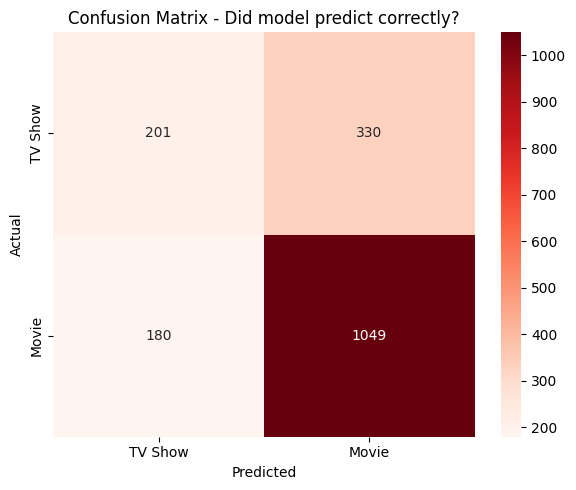

In [43]:
# Step 7 - Confusion Matrix Chart
# Shows how many predictions were correct vs wrong
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['TV Show', 'Movie'],
            yticklabels=['TV Show', 'Movie'])
plt.title('Confusion Matrix - Did model predict correctly?')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

The model successfully predicts whether a Netflix title is a Movie or TV Show with ~71% accuracy. Duration is the strongest predictor since Movies have fixed minute durations while TV Shows are counted in Seasons.